# Conditional probability

## 1. Intuition

In the real world, almost nothing happens in isolation. The probability that someone buys a product changes if they already clicked on the ad. The probability that a patient has a disease changes if they already tested positive. Conditional probability is the tool that lets us update what we know when new information arrives. In ML, it shows up in key places: Naive Bayes uses it directly, Bayesian networks are built on it, and Bayes' theorem (which we will cover in this notebook) is just conditional probability rearranged.

## 2. Mathematical foundation

### 2.1 Conditional Probability

Let $A$ and $B$ be two events. The conditional probability of $A$ given $B$, meaning the probability of $A$ given that $B$ has already occurred, is written as $P( A \mid B )$ and is defined as:

$$
P( A \mid B )= 	\frac{P(A \cap B)}{P(B)}, \quad provided \; P(B)>0
$$

**Intuition behind the definition**

When we know that $B$ has already occurred, $B$ becomes the new sample space. We are no longer looking at all possible outcomes, only at the ones where $B$ happened. In that reduced space, we ask: how much of $B$ also contains $A$? That ratio is $P( A \mid B )$.


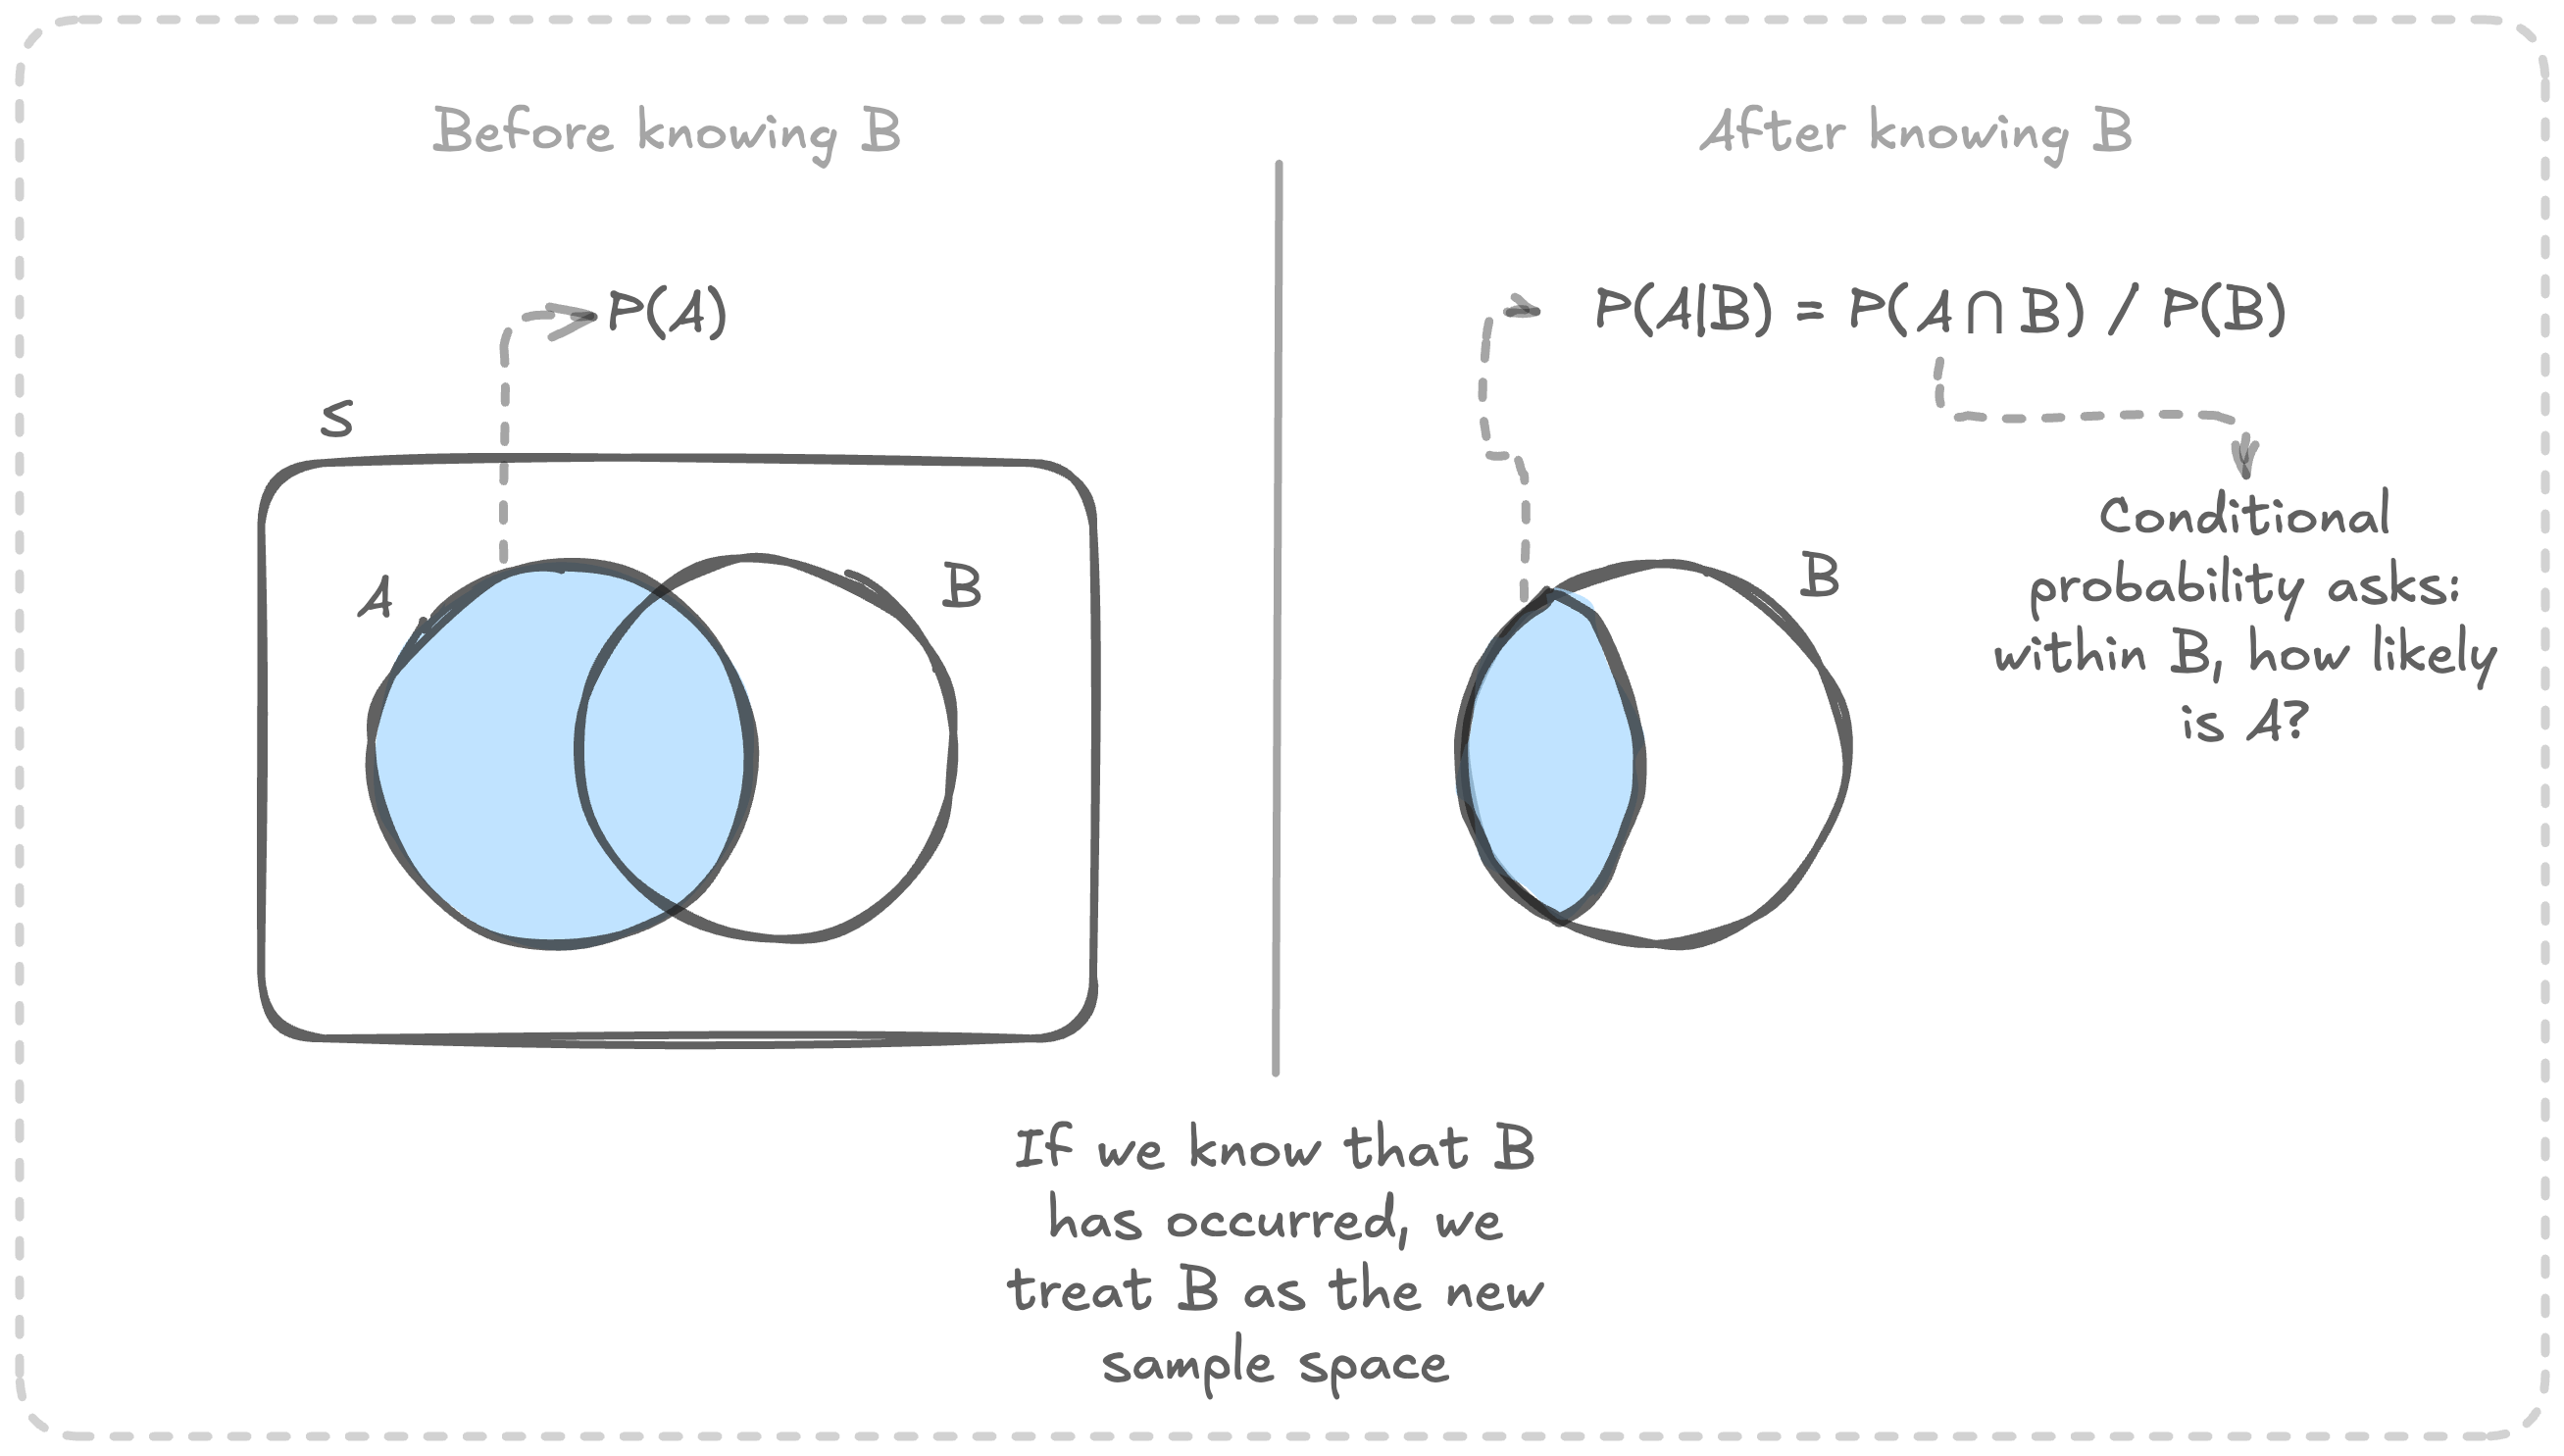

*Figure 1: Venn diagram: A becomes the new sample space*


**Where the formula comes from**

When all outcomes are equally likely, we can write probabilities as counts:

$$
P(A \cap B)=\frac{|A \cap B|}{|S|}​, \quad P(B)=\frac{|B|}{|S|}
$$

Dividing one by the other, $|S|$ cancels and we get the formula. Note that this only works when all outcomes are equally likely. The definition above holds in general.



### 2.2 Law of Total Probability

Let $B_1,B_2,\ldots,B_n$, be a partition of the sample space $S$, meaning:
* They are **pairwise mutually exclusive:**  $B_i \cap B_j = \emptyset$ for $i \neq j$
* They are **exhaustive:** $B_1 \cup B_2 \cup \cdots \cup B_n = S$

Then for any event $A$:

$$P(A) = \sum_{i=1}^{n} P(A \mid B_i)\, P(B_i)$$

**Note:** Recall that for mutually exclusive events, probability is additive: if $B_i \cap B_j = \emptyset$ , then $P(B_i \cup B_j) = P(B_i) + P(B_j)$. This extends to any finite collection of mutually exclusive events.*

**Proof**

Since $B_1, \ldots, B_n$ is a partition of $S$, we can write $A$ as:

$$A = A \cap S = A \cap (B_1 \cup B_2 \cup \cdots \cup B_n) = (A \cap B_1) \cup (A \cap B_2) \cup \cdots \cup (A \cap B_n)$$

This step uses **exhaustiveness:** because the $B_i$ cover all of $S$, intersecting $A$ with $S$ is the same as intersecting $A$ with the union of all $B_i$. If the $B_i$ were not exhaustive, this equality would not hold and we would be missing part of $A$.

Since the $B_i$ are pairwise mutually exclusive, the sets $A \cap B_i$ are also pairwise mutually exclusive. This step uses **mutual exclusivity:** it guarantees that the sets $A \cap B_i$ do not overlap, which is required to apply the additivity axiom in the next step. If the $B_i$ were not mutually exclusive, the sets $A \cap B_i$ could overlap and we would be counting some probability twice.

Applying the the probability measure and the additivity axiom, since the sets $A \cap B_i$ are pairwise disjoint:

$$P(A) = \sum_{i=1}^{n} P(A \cap B_i)$$

Finally, applying the definition of conditional probability to each term:

$$P(A) = \sum_{i=1}^{n} P(A \mid B_i)\, P(B_i)$$


### 2.3 Bayes' Theorem

Let $B_1, B_2, \ldots, B_n$ be a partition of the sample space $S$, and let $A$ be any event with $P(A)>0$. Then for any $k$:

$$P(B_k \mid A) = \frac{P(A \mid B_k)\, P(B_k)}{\sum_{i=1}^{n} P(A \mid B_i)\, P(B_i)}$$

The denominator is exactly the Law of Total Probability, so this can also be written as:

$$P(B_k \mid A) = \frac{P(A \mid B_k)\, P(B_k)}{P(A)}$$

**Intuition: reasoning backwards from effect to cause**

Think of $A$ as an effect that already happened, and $B_1, \ldots, B_n$ as the possible causes. Bayes' theorem lets you ask: given that the effect occurred, what is the probability that each cause was responsible? This is why it is sometimes called the theorem of the causes, becouse you are reasoning backwards from what you observed to what might have caused it.

**Proof**

The proof follows directly from the definition of conditional probability and the Law of Total Probability.

By the definition of conditional probability:

$$P(B_k \mid A) = \frac{P(A \cap B_k)}{P(A)}$$

Applying the definition of conditional probability again to the numerator:

$$P(A \cap B_k) = P(A \mid B_k)\, P(B_k)$$

Replacing the denominator using the Law of Total Probability:

$$P(A) = \sum_{i=1}^{n} P(A \mid B_i)\, P(B_i)$$

Putting it all together:

$$P(B_k \mid A) = \frac{P(A \mid B_k)\, P(B_k)}{\sum_{i=1}^{n} P(A \mid B_i)\, P(B_i)}$$


### 2.4 Independence

Two events $A$ and $B$ are independent if knowing that one occurred does not change the probability of the other:

$$P(A \mid B) = P(A)$$

Note that this requires $P(B) > 0$ for the conditional probability to be defined. For this reason, the formal definition of independence is usually stated as:

$$P(A \cap B) = P(A)\, P(B)$$

This version has no restrictions on $P(A)$ or $P(B)$.

**Equivalence of both forms**

If $P(B)>0$, both definitions are equivalent. Starting from the definition of conditional probability:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

If $P(A \cap B) = P(A)\,P(B)$, substituting:

$$P(A \mid B) = \frac{P(A)\,P(B)}{P(B)} = P(A)$$

The same steps work in reverse, so both forms are equivalent when $P(B) > 0$.

**Important distinction: independence vs mutual exclusivity**

These two concepts are often confused in interviews. Two events are mutually exclusive if they cannot happen at the same time: $P(A \cap B) = 0$. Two events are independent if knowing one does not change the probability of the other: $P(A \cap B) = P(A)P(B)$.

If two events are mutually exclusive and both have positive probability, they are actually dependent, because if one occurs you know for certain the other did not.

## 3. Assumptions

**Conditional probability** requires $P(B) > 0$. If the conditioning event has probability zero, the conditional probability is not defined.

**Law of Total Probability** requires that $B_1, B_2, \ldots, B_n$ form a partition of $S$, meaning they are pairwise mutually exclusive and exhaustive. If this condition is not met, the sum will not add up to $P(A)$ correctly.

**Bayes' Theorem** requires the same partition condition as above, plus $P(A) > 0$. It also inherits the assumption of conditional probability since it is built on top of it.

**Independence** has no special assumptions beyond working within a valid probability space. The definition $P(A \cap B) = P(A)P(B)$ holds without any restrictions on $P(A)$ or $P(B)$.

## 4. Worked Examples

### 4.1 Conditional Probability

**Problem**

You have a dataset of weather observations. Each observation records the weather condition (X) and whether people went outside (Y). Given the data below, compute $P(Y = \text{yes} \mid X = \text{sunny})$.

In [2]:
data = [
    ("sunny", "yes"),
    ("sunny", "yes"),
    ("sunny", "no"),
    ("rainy", "no"),
    ("rainy", "no"),
    ("cloudy", "yes"),
    ("sunny", "yes"),
    ("rainy", "no"),
    ("cloudy", "no"),
    ("sunny", "yes"),
]

**Solution**

By definition:

$$P(Y = \text{yes} \mid X = \text{sunny}) = \frac{P(Y = \text{yes} \cap X = \text{sunny})}{P(X = \text{sunny})}$$

We count directly from the data:
- Total observations: 10
- Observations where $X = \text{sunny}$: 5
- Observations where $X = \text{sunny}$ and $Y = \text{yes}$: 4

$$P(Y = \text{yes} \mid X = \text{sunny}) = \frac{4/10}{5/10} = \frac{4}{5} = 0.8$$


In [3]:
def conditional_probability(data, x, y):
    # P(X = x): filter observations where X = x (new sample space)
    x_events = [obs for obs in data if obs[0] == x]
    if len(x_events) == 0:
        return 0.0
    # P(X = x AND Y = y): filter where both conditions hold
    xy_events = [obs for obs in x_events if obs[1] == y]
    # P(Y = y | X = x) = P(X = x AND Y = y) / P(X = x)
    return len(xy_events) / len(x_events)

result = conditional_probability(data, "sunny", "yes")
print(f"P(Y=yes | X=sunny) = {result}")

P(Y=yes | X=sunny) = 0.8


### 4.2 Law of Total Probability

**Problem**

A factory has three production lines. Line A produces 50% of all items, line B produces 30%, and line C produces 20%. The defect rates are 2%, 4%, and 5% respectively. What is the overall probability that a randomly selected item is defective?

**Solution**

The three production lines form a partition of the sample space since every item comes from exactly one line and together they cover 100% of production.

Let $D$ be the event "item is defective". By the Law of Total Probability:

$$P(D) = P(D \mid A)\,P(A) + P(D \mid B)\,P(B) + P(D \mid C)\,P(C)$$

$$P(D) = (0.02)(0.50) + (0.04)(0.30) + (0.05)(0.20)$$

$$P(D) = 0.010 + 0.012 + 0.010 = 0.032$$

There is a 3.2% probability that a randomly selected item is defective.

In [ ]:
def total_probability(priors, conditionals):
    # P(A) = sum of P(A|Bi) * P(Bi) for all i
    return round(sum(conditionals[b] * priors[b] for b in priors), 4)

priors = {"A": 0.50, "B": 0.30, "C": 0.20}
conditionals = {"A": 0.02, "B": 0.04, "C": 0.05}

result = total_probability(priors, conditionals)
print(f"P(defective) = {result}")

### 4.3 Bayes' Theorem

**Problem**

80% of Netflix users are "normal" raters: they give thumbs up 60% of the time. The other 20% are "lazy" raters: they give thumbs up 100% of the time. Given that a user gave thumbs up to 3 movies in a row, what is the probability that they are a lazy rater?

**Solution**

We define the following events:

- $A$: the user gave thumbs up to 3 movies in a row
- $B_1$: the user is a normal rater, $P(B_1) = 0.8$
- $B_2$: the user is a lazy rater, $P(B_2) = 0.2$

Since each rating is independent:

$$P(A \mid B_1) = 0.6 \times 0.6 \times 0.6 = 0.216$$

$$P(A \mid B_2) = 1 \times 1 \times 1 = 1$$

Applying the Law of Total Probability:

$$P(A) = P(A \mid B_1)P(B_1) + P(A \mid B_2)P(B_2)$$

$$P(A) = (0.216)(0.8) + (1)(0.2) = 0.1728 + 0.2 = 0.3728$$

Applying Bayes' Theorem:

$$P(B_2 \mid A) = \frac{P(A \mid B_2)\,P(B_2)}{P(A)} = \frac{(1)(0.2)}{0.3728} \approx 0.5364$$

Even though only 20% of users are lazy raters, seeing 3 thumbs up in a row raises that probability to 53.6%. This is Bayes' theorem in action: the evidence updates the initial belief.


In [4]:
def bayes_theorem(priors, likelihoods):
    # P(A) using Law of Total Probability
    total = sum(likelihoods[h] * priors[h] for h in priors)
    # P(Bi|A) for each hypothesis
    posteriors = {h: round((likelihoods[h] * priors[h]) / total, 4) for h in priors}
    return posteriors

priors = {"normal": 0.8, "lazy": 0.2}
likelihoods = {"normal": 0.6**3, "lazy": 1.0**3}

posteriors = bayes_theorem(priors, likelihoods)
print(f"P(normal | 3 thumbs up) = {posteriors['normal']}")
print(f"P(lazy   | 3 thumbs up) = {posteriors['lazy']}")

P(normal | 3 thumbs up) = 0.4635
P(lazy   | 3 thumbs up) = 0.5365


### 4.4 Independence

**Problem**

A small e-commerce platform recorded the behavior of 15 users in one day. For each user we know whether they opened a promotional email and whether they made a purchase. Are these two events independent?


In [5]:
import pandas as pd

data = {
    "opened_email": [1,1,1,1,1,1,0,0,0,0,0,0,0,0,0],
    "purchased":    [1,1,0,0,0,0,1,1,1,0,0,0,0,0,0]
}

df = pd.DataFrame(data)
print(pd.crosstab(df["opened_email"], df["purchased"], margins=True))

purchased      0  1  All
opened_email            
0              6  3    9
1              4  2    6
All           10  5   15


**Solution**

Let $A$ be the event "user opened the email" and $B$ be the event "user made a purchase".

$$P(A) = \frac{6}{15} \qquad P(B) = \frac{5}{15} \qquad P(A \cap B) = \frac{2}{15}$$

We check the independence condition:

$$P(A) \cdot P(B) = \frac{6}{15} \cdot \frac{5}{15} = \frac{2}{15} = P(A \cap B)$$

The condition holds, so $A$ and $B$ are independent. We can also verify using conditional probability:

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{2/15}{5/15} = \frac{2}{5} = P(A)$$

Knowing that a user made a purchase does not change the probability that they opened the email.

**A note on independence in practice**

In this example I verified independence by checking the exact equality $P(A \cap B) = P(A)P(B)$. In practice, with real data, this equality will almost never hold exactly due to sampling variation. Instead, independence is tested using a chi-squared test, which evaluates whether the association observed in the data could be explained by chance. I will cover this in notebook 06.

It is also important to note that statistical independence does not prove the absence of causality. Two variables can be statistically independent and still have an indirect causal relationship, or they can be associated without any causal connection. When you need to prove causality, you need a controlled experiment such as an A/B test, not just observational data. I will cover this in notebook 19.

## 5. Real Industry Use Case

**Spam filters: how email clients classify your inbox**

One of the earliest and most well-known applications of conditional probability and Bayes' theorem in the industry is email spam filtering. In 1998, Sahami et al. published the first academic work on this topic, proposing a Bayesian approach to classifying emails as spam or not spam. That work was soon adopted in commercial spam filters and is the foundation of tools like SpamAssassin, which is still widely used today.

The idea connects directly to everything in this notebook. Each word in an email becomes a piece of evidence. The filter estimates the conditional probability that an email is spam given that it contains certain words, for example P(spam | "free", "win", "prize"). Bayes' theorem is then used to reverse this reasoning: starting from how often those words appear in known spam emails (the likelihood), and how common spam is in general (the prior), the filter calculates the probability that the email is spam.

The independence assumption is also central here. The model assumes that each word is independent of the others given the class (spam or not spam). This is the "naive" assumption in Naive Bayes, and while it is not realistic in practice, it simplifies the calculation enormously and still produces good results.

**Reference:** Sahami, M., Dumais, S., Heckerman, D., and Horvitz, E. (1998). *A Bayesian approach to filtering junk e-mail*. AAAI Workshop on Learning for Text Categorization.

## 6. How to Explain It to a Non-Technical Stakeholder

### Conditional probability

In real life, new information changes what we know, and that changes the probabilities. Imagine you want to know if it will rain today. Without any extra information, you might say there is a 10% chance of rain. But then you look outside and see cloudy skies. Now that 10% goes up, maybe to 60%, because clouds are a sign of rain. The probability did not change by itself. It changed because you learned something new. That is conditional probability: the probability of something happening, given that you already know something else.

### Law of total probability

Sometimes you want to know the overall chance of something happening, but that thing can happen through different paths. Think of a factory with three production lines. Each line produces a different share of the total output, and each line has a different defect rate. If you want to know the overall defect rate for the whole factory, you cannot just average the three rates. You have to take into account how much each line contributes. The law of total probability is just a formal way of doing that: add up all the paths that can lead to the outcome, weighted by how likely each path is.

### Bayes' theorem

Imagine you are locked in a room and someone asks you: is it sunny or rainy outside? You think about it and say: probably sunny, because most days are sunny. Then the door opens and someone walks in carrying an umbrella. You immediately update your answer: maybe it is raining after all. That is Bayes' theorem in everyday life. You started with a belief (probably sunny), you got new evidence (the umbrella), and you updated your belief. Bayes' theorem is just the mathematical formula for doing that update in a precise way.

A common mistake people make is trusting a test result too much without thinking about how rare the thing being tested actually is. If a disease affects 1 in 1,000 people and a test gives a false positive 5% of the time, then most people who test positive do not actually have the disease. Bayes' theorem is what tells you that.

### Independence

Two events are independent when knowing the result of one does not tell you anything about the other. If you flip a coin twice, the result of the first flip does not affect the second one at all. But if you draw two cards from a deck without putting the first one back, the second draw is affected by the first. Those two events are not independent. In data science, checking for independence matters because if two variables are not independent, one of them carries information about the other, and that is useful for building models.

## 7. Interview Questions



### Conceptual questions

**1. What is conditional probability and how is it different from joint probability?**

Conditional probability is the probability of event A given that event B has already occurred: $P(A|B) = P(A \cap B) / P(B)$. It assumes B has happened and asks how likely A is in that reduced space. Joint probability is just the probability that both A and B happen at the same time: $P(A \cap B)$, with no assumption about either event having occurred first.

**2. What does it mean for two events to be independent?**

Two events are independent if knowing that one occurred does not change the probability of the other: $P(A|B) = P(A)$. Equivalently, $P(A \cap B) = P(A)P(B)$. The second form is the formal definition because it does not require $P(B) > 0$.

**3. What is the difference between independence and mutual exclusivity?**

Mutual exclusivity means two events cannot happen at the same time: $P(A \cap B) = 0$. Independence means knowing one event occurred does not affect the probability of the other. These two concepts are often confused, but they are actually opposite in a sense: if two events are mutually exclusive and both have positive probability, they are dependent, because if one occurs you know for certain the other did not.

**4. What is Bayes' theorem and when would you use it?**

Bayes' theorem lets you update the probability of a hypothesis after observing new evidence:

$$P(B_k \mid A) = \frac{P(A \mid B_k)\, P(B_k)}{\sum_{i} P(A \mid B_i)\, P(B_i)}$$

You use it when you know the likelihood of the evidence given each hypothesis, and you want to reverse that to find the probability of each hypothesis given the evidence. Common applications include medical diagnosis, spam filtering, and Bayesian classifiers.

---

### Application questions

**5. A test for a disease has 99% accuracy. The disease affects 1 in 10,000 people. If someone tests positive, what is the probability they actually have the disease?**

This is a classic Bayes' theorem problem. Let $D$ be the event "has the disease" and $T$ be the event "tests positive".

$$P(D) = 0.0001, \quad P(T|D) = 0.99, \quad P(T|\neg D) = 0.01$$

$$P(T) = P(T|D)P(D) + P(T|\neg D)P(\neg D)$$
$$P(T) = (0.99)(0.0001) + (0.01)(0.9999) = 0.000099 + 0.009999 = 0.010098$$

$$P(D|T) = \frac{P(T|D)P(D)}{P(T)} = \frac{0.000099}{0.010098} \approx 0.0098$$

Even with a 99% accurate test, a positive result means only about 1% chance of actually having the disease, because the disease is so rare. This is why Bayes' theorem matters in practice.

**6. You are building a recommendation system. How would you use conditional probability to estimate the probability that a user will click on a product given that they already clicked on a similar one?**

You would estimate $P(\text{click on B} \mid \text{clicked on A})$ from historical data. Count the number of users who clicked on both A and B, divided by the number of users who clicked on A. This gives you a data-driven conditional probability that you can use to rank recommendations. If this probability is higher than the baseline click rate $P(\text{click on B})$, then clicking on A is informative and the two products are not independent.

**7. You run an A/B test and 5% of users in group A convert, and 8% in group B. Are these results independent of the group assignment? How would you check?**

If conversion were independent of group assignment, the conversion rate would be the same in both groups. The fact that the rates differ suggests dependence, but you need a statistical test to confirm it is not due to chance. You would use a chi-squared test of independence on the contingency table of group vs. conversion outcome. If the p-value is below your significance threshold, you reject independence and conclude that group assignment affects conversion.

---

### Conceptual traps

**8. If $P(A|B) = P(A)$, what can you say about A and B?**

A and B are independent. Knowing B occurred does not change the probability of A. This also implies $P(B|A) = P(B)$ and $P(A \cap B) = P(A)P(B)$.

**9. Can two mutually exclusive events be independent? Why or why not?**

No, not if both events have positive probability. If A and B are mutually exclusive, then $P(A \cap B) = 0$. For independence we would need $P(A \cap B) = P(A)P(B)$. This is only possible if $P(A) = 0$ or $P(B) = 0$. So in practice, mutually exclusive events with positive probability are always dependent: if one occurs, the other cannot, which means knowing one occurred gives you information about the other.

## 8. Did You Know?



The theorem at the center of this notebook has one of the most unusual origin stories in mathematics.

Thomas Bayes was a Presbyterian minister, not a professional mathematician. He never published the theorem during his lifetime. When he died in 1761, his friend Richard Price found the manuscript among his papers and sent it to the Royal Society in 1763, where it was read out loud on December 23rd of that year. The foundation of modern machine learning was published two years after its author's death, by a friend who recognized its importance.

What makes the story even more interesting is that Price's motivation for publishing it was partly philosophical: he believed the theorem could be used to argue for the existence of God, as a mathematical way of showing that the order observed in nature is evidence of an intelligent cause. A theorem now used to filter your spam email was originally connected to a theological debate.

A few years later, in 1774, the French mathematician Pierre-Simon Laplace rediscovered the same theorem completely independently, without knowing Bayes had already developed it. It was Laplace who gave it its modern mathematical form and applied it broadly to science. As one historian put it, Laplace did most of the hard work, but the name stayed with Bayes.

For much of the 19th and early 20th centuries, Bayesian methods were rejected by the statistics community as too subjective. It was not until computers became powerful enough to run the necessary calculations, in the latter half of the 20th century, that Bayes' theorem became widely used. A theorem that waited over 200 years to reach its full potential.